# Live CheXpert Prediction Demo with File Explorer — ConvNeXt-Tiny LSR

This notebook opens the **Windows file explorer**, lets you select a chest X-ray image, runs live multi-label classification using the trained **ConvNeXt-Tiny + Hybrid2 LSR** model, and generates a Grad-CAM explanation.

**Use in presentation:** execute the cells in order, click/select a chest X-ray image, and show the probability table + Grad-CAM output.

> Educational demo only. Not intended for clinical diagnosis.


In [23]:
# 1. Imports

from __future__ import annotations

import json
import io
from pathlib import Path
from typing import Dict, List, Optional, Union

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

import matplotlib.pyplot as plt
from IPython.display import display

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configuration

The notebook is configured for your local Windows project. Check that the paths exist before running the live demo.


In [24]:
# 2. Project configuration

PROJECT_DIR = Path(r"C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project")

MODEL_NAME = "convnext_tiny"
TAG = "convnext_tiny_kaggle80k_320_lsr"
STRATEGY = "kaggle80k_hybrid2_lsr_frontal"

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
]

CHECKPOINT_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}_{TAG}_{STRATEGY}_best.pt"
RESULTS_DIR = PROJECT_DIR / "results" / TAG
THRESHOLDS_PATH = RESULTS_DIR / "best_thresholds_f1.json"

OUTPUT_DIR = PROJECT_DIR / "deliverables" / "live_filepicker_demo_convnext_lsr" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Default folder opened by the file explorer.
DEFAULT_IMAGE_DIR = Path(r"C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\archive\train")

# Optional: set a class manually, or leave None to explain the highest-probability prediction.
CLASS_TO_EXPLAIN = None  # Example: "Pleural Effusion", "Cardiomegaly", "Edema"

print("Checkpoint exists:", CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)
print("Thresholds exist:", THRESHOLDS_PATH.exists(), THRESHOLDS_PATH)
print("Default image directory exists:", DEFAULT_IMAGE_DIR.exists(), DEFAULT_IMAGE_DIR)
print("Output directory:", OUTPUT_DIR)


Checkpoint exists: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\models\convnext_tiny_convnext_tiny_kaggle80k_320_lsr_kaggle80k_hybrid2_lsr_frontal_best.pt
Thresholds exist: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\results\convnext_tiny_kaggle80k_320_lsr\best_thresholds_f1.json
Default image directory exists: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\archive\train
Output directory: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\live_filepicker_demo_convnext_lsr\outputs


## 3. Model and Grad-CAM utilities

This cell builds the ConvNeXt-Tiny model, loads the trained LSR checkpoint, preprocesses images, predicts labels, and generates Grad-CAM.


In [25]:
# 3. Model and Grad-CAM utilities

class GradCAM:
    """Minimal Grad-CAM implementation for CNN-like feature maps."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        if self.activations is None or self.gradients is None:
            raise RuntimeError("Grad-CAM hooks did not capture activations/gradients.")

        if self.activations.ndim != 4 or self.gradients.ndim != 4:
            raise RuntimeError(
                f"Expected 4D feature maps, got activations={self.activations.shape}, gradients={self.gradients.shape}"
            )

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam_tensor = (weights * self.activations).sum(dim=1, keepdim=True)
        cam_tensor = F.relu(cam_tensor)
        cam_tensor = F.interpolate(cam_tensor, size=x.shape[-2:], mode="bilinear", align_corners=False)

        cam = cam_tensor[0, 0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def build_convnext_tiny(num_labels: int, dropout: float = 0.40):
    weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = models.convnext_tiny(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_labels),
    )

    mean = weights.transforms().mean
    std = weights.transforms().std
    target_layer = model.features[-1]
    return model, mean, std, target_layer


def load_model(checkpoint_path: Path):
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    labels = checkpoint.get("target_labels", LABELS)
    config = checkpoint.get("config", {})
    dropout = float(config.get("dropout", 0.40))
    img_size = int(config.get("img_size", 320))

    model, mean, std, target_layer = build_convnext_tiny(num_labels=len(labels), dropout=dropout)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return model, labels, mean, std, target_layer, img_size, device


def load_thresholds(thresholds_path: Path, labels: List[str]) -> Dict[str, float]:
    if thresholds_path.exists():
        with open(thresholds_path, "r", encoding="utf-8") as f:
            return json.load(f)
    print("Threshold file not found. Using 0.5 for every class.")
    return {label: 0.5 for label in labels}


def preprocess_image_from_pil(image: Image.Image, img_size: int, mean, std, device):
    image = image.convert("RGB")
    preprocess = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    tensor = preprocess(image).unsqueeze(0).to(device)
    return image, tensor


def preprocess_image_from_path(image_path: Path, img_size: int, mean, std, device):
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = Image.open(image_path).convert("RGB")
    return preprocess_image_from_pil(image, img_size, mean, std, device)


def overlay_cam_on_image(image: Image.Image, cam: np.ndarray, alpha: float = 0.42) -> np.ndarray:
    image_resized = image.resize((cam.shape[1], cam.shape[0]))
    base = np.asarray(image_resized).astype(np.float32) / 255.0
    heatmap = plt.get_cmap("jet")(cam)[..., :3]
    overlay = (1.0 - alpha) * base + alpha * heatmap
    return np.clip(overlay, 0.0, 1.0)


def predict_and_explain(
    image_input: Union[str, Path, Image.Image],
    class_to_explain: Optional[str] = None,
    save_prefix: str = "live_filepicker",
):
    model, labels, mean, std, target_layer, img_size, device = load_model(CHECKPOINT_PATH)
    thresholds = load_thresholds(THRESHOLDS_PATH, labels)

    if isinstance(image_input, Image.Image):
        image, input_tensor = preprocess_image_from_pil(image_input, img_size, mean, std, device)
        image_name = "uploaded_image"
        image_path_print = "Uploaded image"
    else:
        image_path = Path(image_input)
        image, input_tensor = preprocess_image_from_path(image_path, img_size, mean, std, device)
        image_name = image_path.stem
        image_path_print = str(image_path)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits).detach().cpu().numpy()[0]

    pred_table = pd.DataFrame({
        "label": labels,
        "probability": [float(probs[i]) for i in range(len(labels))],
        "threshold": [float(thresholds.get(label, 0.5)) for label in labels],
    })
    pred_table["prediction"] = pred_table["probability"] >= pred_table["threshold"]
    pred_table = pred_table.sort_values("probability", ascending=False).reset_index(drop=True)

    if class_to_explain is None:
        class_name = pred_table.iloc[0]["label"]
    else:
        if class_to_explain not in labels:
            raise ValueError(f"Unknown class: {class_to_explain}. Valid labels: {labels}")
        class_name = class_to_explain

    class_idx = labels.index(class_name)

    gradcam = GradCAM(model, target_layer)
    cam = gradcam(input_tensor, class_idx)
    gradcam.close()

    overlay = overlay_cam_on_image(image, cam)

    safe_class = class_name.replace(" ", "_").replace("/", "_")
    safe_image = image_name.replace(" ", "_").replace("/", "_")
    out_csv = OUTPUT_DIR / f"{save_prefix}_{safe_image}_prediction_table.csv"
    out_png = OUTPUT_DIR / f"{save_prefix}_{safe_image}_gradcam_{safe_class}.png"
    pred_table.to_csv(out_csv, index=False)

    print("Selected image:", image_path_print)
    print("Class explained:", class_name)
    display(pred_table)

    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image.resize((img_size, img_size)), cmap="gray")
    ax1.set_title("Input chest X-ray")
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(overlay)
    prob = float(pred_table[pred_table["label"] == class_name]["probability"].iloc[0])
    ax2.set_title(f"Grad-CAM: {class_name}\nProbability: {prob:.3f}")
    ax2.axis("off")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved prediction table:", out_csv)
    print("Saved Grad-CAM:", out_png)

    return pred_table, out_png


## 4. Load model once to verify everything works

Run this cell before the live demo. It confirms that the checkpoint and thresholds are readable.


In [26]:
# 4. Load and verify model

model, labels, mean, std, target_layer, img_size, device = load_model(CHECKPOINT_PATH)
thresholds = load_thresholds(THRESHOLDS_PATH, labels)

print("Model loaded successfully.")
print("Device:", device)
print("Image size:", img_size)
print("Labels:", labels)
print("Thresholds:")
for label in labels:
    print(f"  {label}: {thresholds.get(label, 0.5):.2f}")

# Free memory before the live cells reload the model for prediction.
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Model loaded successfully.
Device: cuda
Image size: 320
Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
Thresholds:
  Atelectasis: 0.34
  Cardiomegaly: 0.45
  Consolidation: 0.35
  Edema: 0.40
  Pleural Effusion: 0.56


## 5. Open Windows File Explorer and select an image

Run the next cell. A Windows file explorer window should open. Select a `.jpg`, `.jpeg`, `.png`, or `.bmp` chest X-ray image.

If the explorer window opens behind VS Code/Jupyter, check the taskbar.


Selected image path: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\sample_valid_images_for_live_demo\sample_14_patient64545_study1_view1_frontal.jpg


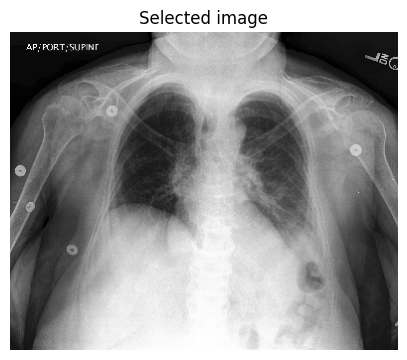

In [27]:
# 5. File explorer selector using tkinter

def select_image_with_file_explorer(initial_dir: Path = DEFAULT_IMAGE_DIR) -> Optional[Path]:
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        root.update()

        file_path = filedialog.askopenfilename(
            title="Select a chest X-ray image",
            initialdir=str(initial_dir if initial_dir.exists() else PROJECT_DIR),
            filetypes=[
                ("Image files", "*.jpg *.jpeg *.png *.bmp"),
                ("JPEG files", "*.jpg *.jpeg"),
                ("PNG files", "*.png"),
                ("All files", "*.*"),
            ],
        )
        root.destroy()

        if not file_path:
            print("No image selected.")
            return None

        return Path(file_path)
    except Exception as exc:
        print("Could not open the file explorer.")
        print("Reason:", repr(exc))
        print("Fallback: set IMAGE_PATH manually in the next cell.")
        return None


SELECTED_IMAGE_PATH = select_image_with_file_explorer()
print("Selected image path:", SELECTED_IMAGE_PATH)

if SELECTED_IMAGE_PATH is not None:
    img = Image.open(SELECTED_IMAGE_PATH).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.title("Selected image")
    plt.axis("off")
    plt.show()


## 6. Classify the selected image and generate Grad-CAM

This is the main live-demo cell. It uses the image selected from the file explorer.


Selected image: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\sample_valid_images_for_live_demo\sample_14_patient64545_study1_view1_frontal.jpg
Class explained: Pleural Effusion


,label,probability,threshold,prediction
0,Pleural Effusion,0.903225,0.56,True
1,Atelectasis,0.589905,0.34,True
2,Edema,0.361525,0.40,False
3,Consolidation,0.212219,0.35,False
4,Cardiomegaly,0.016237,0.45,False


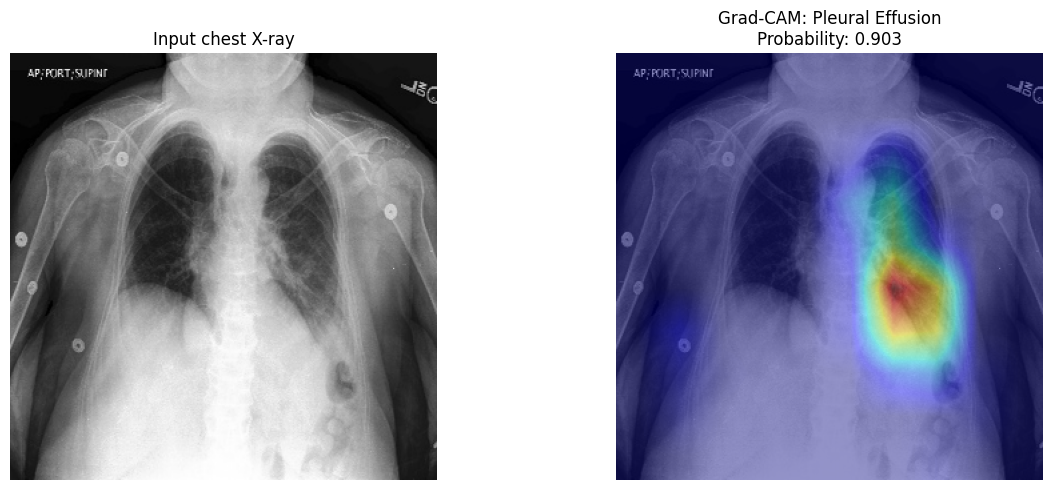

Saved prediction table: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\live_filepicker_demo_convnext_lsr\outputs\convnext_lsr_filepicker_sample_14_patient64545_study1_view1_frontal_prediction_table.csv
Saved Grad-CAM: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\live_filepicker_demo_convnext_lsr\outputs\convnext_lsr_filepicker_sample_14_patient64545_study1_view1_frontal_gradcam_Pleural_Effusion.png


In [28]:
# 6. Live prediction + Grad-CAM from selected file

if SELECTED_IMAGE_PATH is None:
    raise ValueError("No image was selected. Run the file explorer cell again or set SELECTED_IMAGE_PATH manually.")

pred_table, gradcam_path = predict_and_explain(
    image_input=SELECTED_IMAGE_PATH,
    class_to_explain=CLASS_TO_EXPLAIN,  # None = highest probability class
    save_prefix="convnext_lsr_filepicker",
)


## 7. Manual fallback path

Use this if the file explorer does not open in your environment.


In [29]:
# 7. Manual fallback path

# Uncomment and edit this path if needed:
# SELECTED_IMAGE_PATH = Path(r"C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\archive\train\patient00134\study1\view1_frontal.jpg")
# pred_table, gradcam_path = predict_and_explain(SELECTED_IMAGE_PATH, class_to_explain=CLASS_TO_EXPLAIN)


## 8. Optional notebook upload widget

This alternative lets you upload an image directly into the notebook. Use this only if file explorer selection is not convenient.


In [30]:
# 8. Optional upload widget

if not WIDGETS_AVAILABLE:
    print("ipywidgets is not available. Use the file explorer or manual path instead.")
else:
    uploader = widgets.FileUpload(
        accept=".jpg,.jpeg,.png,.bmp",
        multiple=False,
        description="Upload CXR"
    )
    display(uploader)

    def classify_uploaded_image(change=None):
        if len(uploader.value) == 0:
            print("Upload one image first.")
            return

        # Compatible with ipywidgets 7/8 formats
        item = next(iter(uploader.value.values())) if isinstance(uploader.value, dict) else uploader.value[0]
        content = item["content"] if isinstance(item, dict) else item.content
        image = Image.open(io.BytesIO(content)).convert("RGB")

        predict_and_explain(
            image_input=image,
            class_to_explain=CLASS_TO_EXPLAIN,
            save_prefix="convnext_lsr_uploaded",
        )

    button = widgets.Button(description="Classify uploaded image", button_style="success")
    button.on_click(classify_uploaded_image)
    display(button)


FileUpload(value=(), accept='.jpg,.jpeg,.png,.bmp', description='Upload CXR')

Button(button_style='success', description='Classify uploaded image', style=ButtonStyle())